In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
# Read the Dataset
df = pd.read_csv('HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


EDA

In [4]:
print('The number of rows in the dataset are {} and columns are {}'.format(df.shape[0],df.shape[1]))

The number of rows in the dataset are 14999 and columns are 10


In [5]:
# Info of the dataframe
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [6]:
# Chk for null values
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [7]:
# Chk for duplicates
df[ df.duplicated() ]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_level,14999.0,0.612834,0.248631,0.09,0.44,0.64,0.82,1.0
last_evaluation,14999.0,0.716102,0.171169,0.36,0.56,0.72,0.87,1.0
number_project,14999.0,3.803054,1.232592,2.00,3.00,4.00,5.00,7.0
average_montly_hours,14999.0,201.050337,49.943099,96.00,156.00,200.00,245.00,310.0
time_spend_company,14999.0,3.498233,1.460136,2.00,3.00,3.00,4.00,10.0
Work_accident,14999.0,0.144610,0.351719,0.00,0.00,0.00,0.00,1.0
left,14999.0,0.238083,0.425924,0.00,0.00,0.00,0.00,1.0
promotion_last_5years,14999.0,0.021268,0.144281,0.00,0.00,0.00,0.00,1.0


In [9]:
# drop the duplicates
df.drop_duplicates(inplace=True)

In [10]:
df.describe().T #after dropping the duplicates

,count,mean,std,min,25%,50%,75%,max
satisfaction_level,11991.0,0.629658,0.241070,0.09,0.48,0.66,0.82,1.0
last_evaluation,11991.0,0.716683,0.168343,0.36,0.57,0.72,0.86,1.0
number_project,11991.0,3.802852,1.163238,2.00,3.00,4.00,5.00,7.0
average_montly_hours,11991.0,200.473522,48.727813,96.00,157.00,200.00,243.00,310.0
time_spend_company,11991.0,3.364857,1.330240,2.00,3.00,3.00,4.00,10.0
Work_accident,11991.0,0.154282,0.361234,0.00,0.00,0.00,0.00,1.0
left,11991.0,0.166041,0.372133,0.00,0.00,0.00,0.00,1.0
promotion_last_5years,11991.0,0.016929,0.129012,0.00,0.00,0.00,0.00,1.0


In [11]:
# Seperate the categorical columns in to a variable categorical 
# and check for unique values and its value counts

In [12]:
categorical = [var for var in df.columns if df[var].dtype == 'O']
categorical

['sales', 'salary']

In [13]:
numerical = [var for var in df.columns if df[var].dtype != 'O']
numerical

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'left',
 'promotion_last_5years']

In [14]:
for col in categorical:
    print(df[col].value_counts())
    print('*' * 100)

sales
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64
****************************************************************************************************
salary
low       5740
medium    5261
high       990
Name: count, dtype: int64
****************************************************************************************************


In [15]:
# change the name of column from sales to department


In [16]:
df = df.rename(columns={'sales': 'department'})
df.head(2)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium


In [17]:
# in the DF change the category from support => technical & IT => technical in the department column
# total value counts for technical should show as 2244 + 1821 + 976 = 5041

In [18]:
df['department'] = df['department'].replace(['support', 'IT'], 'technical')
df['department'].value_counts()

department
technical      5041
sales          3239
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

In [19]:
# Check for biased dataset
df['left'].value_counts()

left
0    10000
1     1991
Name: count, dtype: int64

Visualization

In [20]:
# Create a scatterplot for those employees that have left the company on the basis of :
# last_evaluation
# satisfaction level
# number of projects & 
# list your findings

In [21]:
# left_df = df[df['left'] == 1]
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=left_df, x='satisfaction_level', y='last_evaluation', hue='number_project', palette='viridis', s=100)
# plt.title('Employees Who Left: Satisfaction vs Last Evaluation by Number of Projects')
# plt.show()

In [22]:
df_left = df[df['left'] == 1]
df_left.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


<Axes: xlabel='last_evaluation', ylabel='satisfaction_level'>

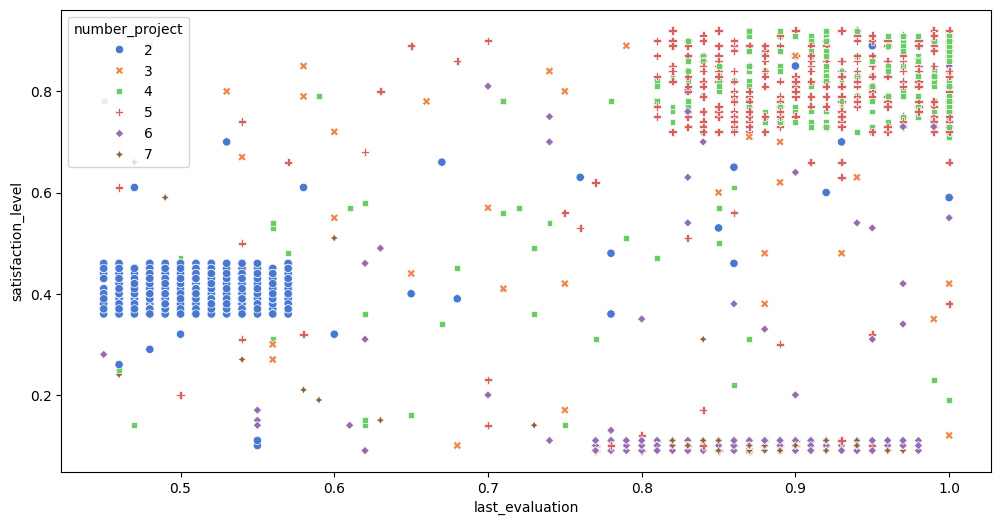

In [23]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data = df_left, x = 'last_evaluation', y = 'satisfaction_level', style='number_project',
               hue = 'number_project', palette='muted')

In [24]:
# Employees with number of projects >= 4 have left the company even if the satisfaction level was high

In [25]:
# Create a scatterplot on last_evaluation, satisfaction level, department and explain your findings

<Axes: xlabel='last_evaluation', ylabel='satisfaction_level'>

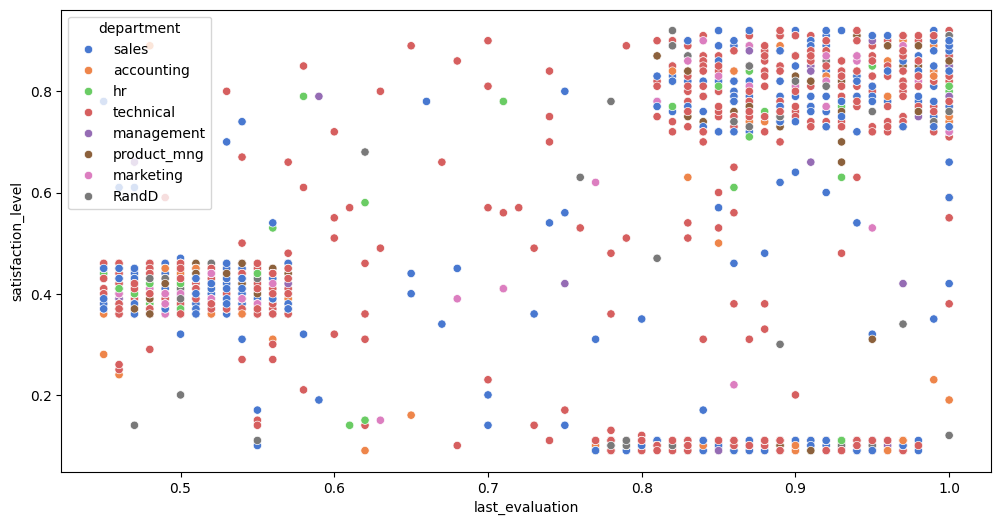

In [26]:

plt.figure(figsize=(12, 6))
sns.scatterplot(data = df_left, x = 'last_evaluation', y = 'satisfaction_level', hue='department',
                palette='muted')

In [27]:
# High attrition depertments are Sales and Technical

In [28]:
# Create a count plot on the column 'department' so that we can see / confirm 
# visually in which department the attrition has been most !

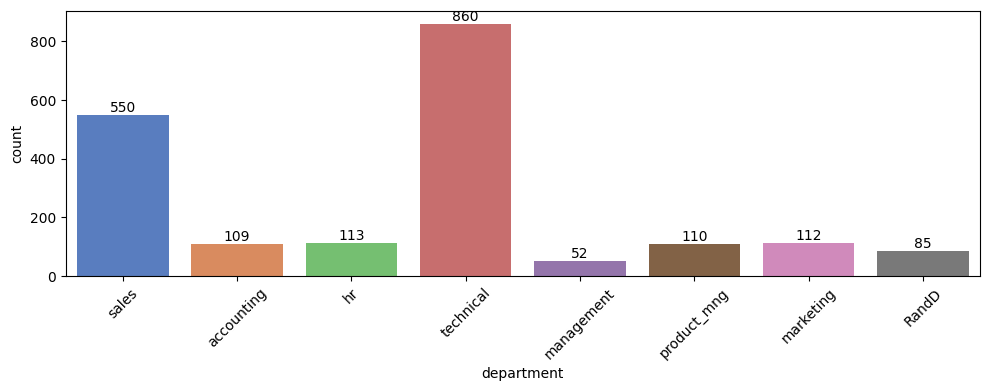

In [29]:
plt.figure(figsize=(10, 4))
ax = sns.countplot(data = df_left, x = 'department', hue = 'department', palette='muted')

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Most of the employees from the technical department have left the company. Next department with max hit is Sales

In [31]:
# Most of the employees from the technical department have left the company. 
# Next department with max hit is Sales

In [32]:
# Analyse average_monthly_hours, time_spend_company, promotion_last_5years

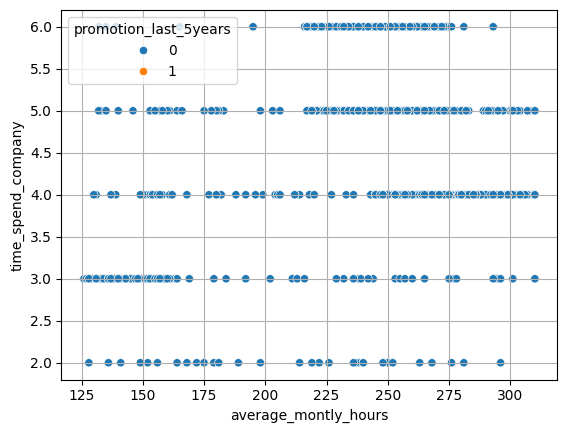

In [36]:
sns.scatterplot(
    data=df_left,
    x='average_montly_hours',   
    y='time_spend_company',
    hue='promotion_last_5years'
)

plt.grid()
plt.show()

In [37]:
# No promotion and high monthly hours

In [38]:
# Create a count plot on the on only Salary

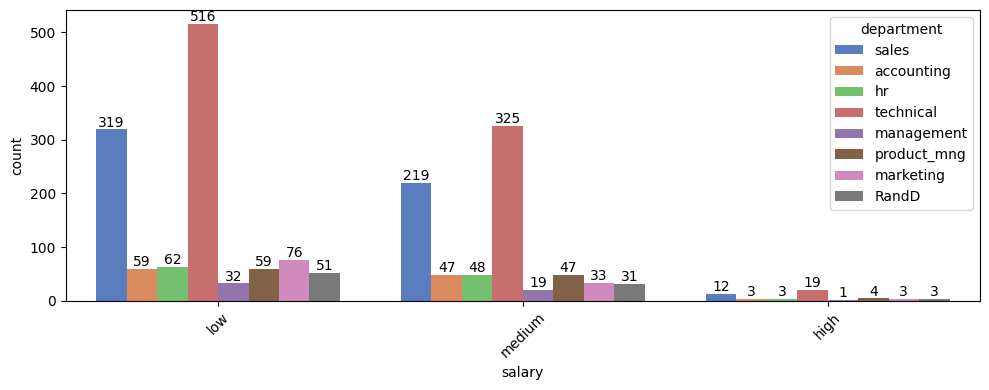

In [41]:
plt.figure(figsize=(10, 4))
ax = sns.countplot(data = df_left, x = 'salary', hue = 'department', palette='muted')

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
# The problem lies in the department and is not related to salary

In [43]:
# Count plot on time_spend_company with respect to salary

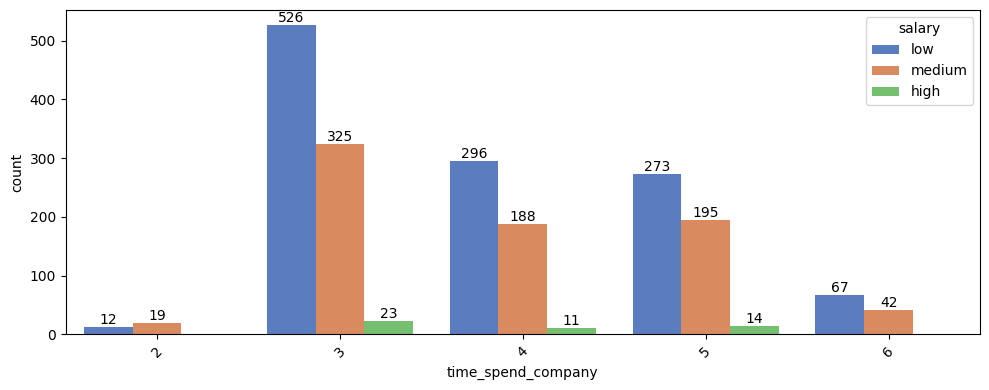

In [44]:
plt.figure(figsize=(10, 4))
ax = sns.countplot(data = df_left, x = 'time_spend_company', hue = 'salary', palette='muted')

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
# Most employees leave in the 3rd year

In [47]:
# Create box plot... chk for outliers

In [48]:
px.box(df, x = ['satisfaction_level', 'last_evaluation'])

In [49]:
px.box(df, x = ['number_project', 'time_spend_company'])

In [50]:
px.box(df, x = ['average_montly_hours'])

In [51]:
df[ df['time_spend_company'] > 5]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
1,0.80,0.86,5,262,6,0,1,0,sales,medium
17,0.78,0.99,4,255,6,0,1,0,sales,low
34,0.84,0.87,4,246,6,0,1,0,hr,low
47,0.57,0.70,3,273,6,0,1,0,technical,low
67,0.90,0.98,4,264,6,0,1,0,product_mng,medium
...,...,...,...,...,...,...,...,...,...,...
11994,0.22,0.94,3,193,10,0,0,1,management,high
11995,0.90,0.55,3,259,10,1,0,1,management,high
11996,0.74,0.95,5,266,10,0,0,1,management,high
11997,0.85,0.54,3,185,10,0,0,1,management,high


In [53]:
# rebuild the categorical list as we changed the column name from sales to department
categorical = [var for var in df.columns if df[var].dtype == 'O']
print(categorical)

['department', 'salary']


In [54]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical:
    df[col] = le.fit_transform(df[col])

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,6,1
1,0.80,0.86,5,262,6,0,1,0,6,2
2,0.11,0.88,7,272,4,0,1,0,6,2
3,0.72,0.87,5,223,5,0,1,0,6,1
4,0.37,0.52,2,159,3,0,1,0,6,1


Split the data into X and y

In [55]:
X = df.drop('left',axis = 1)
y = df.left

In [57]:
X.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,0,6,1
1,0.80,0.86,5,262,6,0,0,6,2
2,0.11,0.88,7,272,4,0,0,6,2
3,0.72,0.87,5,223,5,0,0,6,1
4,0.37,0.52,2,159,3,0,0,6,1


In [59]:
# As the data is imbalanced we will use SMOTE technique & split the data into train and test

In [60]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [62]:
# Build Logistic Reg Model and check its training and testin score along with its cross validation score !

In [73]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [71]:

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=0)
lr.fit(X_train, y_train)
print('Training Score : ', lr.score(X_train, y_train))
print('Testing Score : ', lr.score(X_test, y_test))





Training Score :  0.8036428571428571
Testing Score :  0.802


In [74]:
print('Training Score: ', model.score(X_train, y_train))
print('Testing Score: ', model.score(X_test, y_test))
print('Cross Validation Score: ', cross_val_score(model, X, y, cv=5).mean())

Training Score:  0.8036428571428571
Testing Score:  0.802
Cross Validation Score:  0.80205


In [75]:
# Both Training and Testing scores are close to 80%

In [ ]:
# Build Decision Tree Model and check its training and testin score along with its cross validation score !


In [78]:

from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [79]:
print('Training Score: ', clf.score(X_train, y_train))
print('Testing Score: ', clf.score(X_test, y_test))
print('Cross Validation Score: ', cross_val_score(clf, X, y, cv=5).mean())

Training Score:  1.0
Testing Score:  0.95
Cross Validation Score:  0.9504999999999999


In [80]:
# Both Training and Testing scores are close to 100% & 95%

In [ ]:
# Build Random Forest Model and check its training and testin score along with its cross validation score !
# Use GridSearchCV for finding the RF hyperparameters

In [82]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(criterion='entropy', n_estimators=19)
rf.fit(X_train, y_train)
print('Training Score: ', rf.score(X_train, y_train))
print('Testing Score: ', rf.score(X_test, y_test))
print('Cross Validation Score: ', cross_val_score(rf, X, y, cv=5).mean())

Training Score:  0.9997142857142857
Testing Score:  0.9675
Cross Validation Score:  0.9692000000000001


In [83]:
# Check the hyperparameters using GridSearchCV for RandomForest
from sklearn.model_selection import GridSearchCV
param = {
    'n_estimators' : range(2, 20),
    'criterion' : ['gini', 'entropy']
}
rf = RandomForestClassifier()
grid = GridSearchCV(estimator=rf, param_grid = param)
grid.fit(X, y)
print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'gini', 'n_estimators': 19}
0.97


In [ ]:
# We can use Random Forest Classifier for predicting if an employee will leave the company or not

In [84]:
df[(df['left']==0) & (df['salary']==1) & (df['last_evaluation']>=0.75) & 
                (df['time_spend_company']>=3) & (df['number_project']>2) &
                (df['promotion_last_5years']==0)]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
2003,0.78,0.82,5,247,3,0,0,0,6,1
2005,0.36,0.95,3,206,4,0,0,0,6,1
2007,0.99,0.91,5,136,4,0,0,0,6,1
2008,0.50,0.75,6,127,3,0,0,0,6,1
2028,0.61,0.98,3,267,3,0,0,0,7,1
...,...,...,...,...,...,...,...,...,...,...
11964,0.82,0.80,5,205,3,0,0,0,7,1
11965,0.84,0.81,4,236,3,1,0,0,7,1
11967,0.82,0.82,3,148,3,0,0,0,7,1
11968,0.80,0.80,4,146,3,1,0,0,7,1


In [85]:
# Above list of employees can leave the compant anytime !!

In [86]:
# Suggestions:
# 1. You can use RandonForest Model for future predictions
# 2. Number of project per employee should not be more than 2
# 3. To retain employees with high evaluation and satisfaction level give promotion and increase their salary band.